In [21]:
# Configuración inicial del entorno
import sys
import os
from pathlib import Path

print("🔄 Configurando entorno...")

# Obtener el directorio raíz del proyecto
notebook_dir = Path().resolve()
if notebook_dir.name == "notebooks":
    project_root = notebook_dir.parent
else:
    # Buscar el directorio con pyproject.toml
    project_root = notebook_dir
    while project_root != project_root.parent:
        if (project_root / "pyproject.toml").exists():
            break
        project_root = project_root.parent

print(f"📁 Directorio raíz: {project_root}")

# Cambiar al directorio raíz
os.chdir(project_root)
print(f"✓ Directorio de trabajo: {os.getcwd()}")

# Agregar al path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Verificar pyproject.toml
if (project_root / "pyproject.toml").exists():
    print("✓ pyproject.toml encontrado")
else:
    raise FileNotFoundError(f"pyproject.toml no encontrado en {project_root}")

print("✅ Configuración completada\n")


🔄 Configurando entorno...
📁 Directorio raíz: C:\Users\PC RST\Documents\GitHub\ML_ClashRoyale
✓ Directorio de trabajo: C:\Users\PC RST\Documents\GitHub\ML_ClashRoyale
✓ pyproject.toml encontrado
✅ Configuración completada



# 🎯 Fase 4: Modelado (CRISP-DM)

Este notebook documenta la **cuarta fase de CRISP-DM: Modelado**.  
Se enfoca en el **aprendizaje supervisado** e incluye:

- **Clasificación**: Predecir si el jugador A gana o pierde la batalla (binario 1/0)
- **Regresión**: Predecir el cambio de trofeos del jugador A (A.trophyChange, con signo)

## Objetivos del Modelado

1. **Clasificación Binaria**: 
   - Predecir el resultado de la batalla (victoria/derrota del jugador A)
   - Modelos: Logistic Regression, Random Forest, XGBoost, SVC, LightGBM
   - Métricas: Accuracy, Precision, Recall, F1-Score, ROC-AUC

2. **Regresión**:
   - Predecir el cambio de trofeos del jugador A
   - Modelos: Linear Regression, Ridge, Random Forest, XGBoost, SVR, LightGBM
   - Métricas: MAE, MSE, RMSE, R²

3. **Optimización**:
   - GridSearchCV con Cross-Validation (k≥3 folds)
   - Selección de mejores hiperparámetros
   - Comparación de modelos


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report
)

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Configurar tamaño de figuras
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Librerías importadas exitosamente")


✅ Librerías importadas exitosamente


## 1. Cargar Datos y Resultados de Modelos

### 1.1. Datos de Entrenamiento y Test


In [23]:
# Cargar datos desde Kedro
try:
    print("🔄 Cargando datos desde Kedro...")
    
    # Importar y configurar Kedro
    from kedro.framework.session import KedroSession
    from kedro.framework.startup import bootstrap_project
    
    # Bootstrap del proyecto
    metadata = bootstrap_project(project_root)
    
    # Crear sesión de Kedro
    session = KedroSession.create(project_path=project_root)
    context = session.load_context()
    catalog = context.catalog
    
    # Cargar datos de entrenamiento y test
    try:
        train_data = catalog.load("train_data")
        test_data = catalog.load("test_data")
        print(f"✅ Datos de entrenamiento: {train_data.shape}")
        print(f"✅ Datos de test: {test_data.shape}")
        print(f"   Features: {len([c for c in train_data.columns if c not in ['label', 'target_regression', 'battle_id']])}")
    except Exception as e:
        print(f"⚠ Datos no disponibles en el catálogo: {str(e)[:80]}")
        # Intentar cargar directamente desde archivo
        train_data_path = project_root / "data" / "05_model_input" / "train_data.csv"
        test_data_path = project_root / "data" / "05_model_input" / "test_data.csv"
        
        if train_data_path.exists() and test_data_path.exists():
            train_data = pd.read_csv(train_data_path)
            test_data = pd.read_csv(test_data_path)
            print(f"✅ Datos cargados desde archivos")
        else:
            print(f"❌ Archivos no encontrados")
            train_data = None
            test_data = None
            print("💡 Ejecuta primero: kedro run --pipeline=feature_engineering")
    
except Exception as e:
    print(f"❌ Error al cargar datos: {e}")
    train_data = None
    test_data = None


🔄 Cargando datos desde Kedro...


[11/28/25 17:49:45] WARNING  c:\Users\PC                                                            warnings.py:112
                             RST\Documents\GitHub\ML_ClashRoyale\venv\Lib\site-packages\kedro\frame                
                             work\project\__init__.py:350: UserWarning: The                                        
                             'proyecto_ml_clashroyale.pipelines.nodes' module does not expose a                    
                             'create_pipeline' function, so no pipelines defined therein will be                   
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving plugin.py:243
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[11/28/25 17:49:46] INFO     Loading data from train_data (CSVDataset)...                      data_catalog.py:1048

                    INFO     Loading data from test_data (CSVDataset)...                       data_catalog.py:1048

✅ Datos de entrenamiento: (16032, 113)
✅ Datos de test: (4008, 113)
   Features: 111


### 1.2. Resultados de Clasificación


In [24]:
# Cargar resultados de clasificación
classification_comparison_path = project_root / "data" / "08_reporting" / "classification_comparison.json"

try:
    if classification_comparison_path.exists():
        with open(classification_comparison_path, 'r', encoding='utf-8') as f:
            classification_comparison = json.load(f)
        print("✅ Resultados de clasificación cargados desde archivo")
    else:
        # Intentar cargar desde catálogo
        try:
            classification_comparison = catalog.load("classification_comparison")
            print("✅ Resultados de clasificación cargados desde catálogo")
        except:
            classification_comparison = None
            print("⚠ Resultados de clasificación no disponibles")
            print("💡 Ejecuta: kedro run --pipeline=classification")
except Exception as e:
    print(f"⚠ Error al cargar resultados de clasificación: {e}")
    classification_comparison = None

# Mostrar resumen si está disponible
if classification_comparison and 'models' in classification_comparison:
    n_models = len(classification_comparison['models'])
    print(f"\n📊 Resumen de Clasificación:")
    print(f"   Total de modelos: {n_models}")
    
    # Encontrar el mejor modelo basado en ROC-AUC
    best_model_name = None
    best_roc_auc = -1
    for model_name, model_data in classification_comparison['models'].items():
        if 'metrics' in model_data and 'roc_auc' in model_data['metrics']:
            roc_auc = model_data['metrics']['roc_auc']
            if roc_auc > best_roc_auc:
                best_roc_auc = roc_auc
                best_model_name = model_name
    
    if best_model_name:
        print(f"   Mejor modelo: {best_model_name}")
        print(f"   ROC-AUC: {best_roc_auc:.4f}")
elif classification_comparison:
    print("⚠ Estructura de datos inesperada")


✅ Resultados de clasificación cargados desde archivo

📊 Resumen de Clasificación:
   Total de modelos: 5
   Mejor modelo: XGBoost
   ROC-AUC: 0.5372


### 1.3. Resultados de Regresión


In [25]:
# Cargar resultados de regresión
regression_comparison_path = project_root / "data" / "08_reporting" / "regression_comparison.json"

try:
    if regression_comparison_path.exists():
        with open(regression_comparison_path, 'r', encoding='utf-8') as f:
            regression_comparison = json.load(f)
        print("✅ Resultados de regresión cargados desde archivo")
    else:
        # Intentar cargar desde catálogo
        try:
            regression_comparison = catalog.load("regression_comparison")
            print("✅ Resultados de regresión cargados desde catálogo")
        except:
            regression_comparison = None
            print("⚠ Resultados de regresión no disponibles")
            print("💡 Ejecuta: kedro run --pipeline=regression")
except Exception as e:
    print(f"⚠ Error al cargar resultados de regresión: {e}")
    regression_comparison = None

# Mostrar resumen si está disponible
if regression_comparison and 'models' in regression_comparison:
    n_models = len(regression_comparison['models'])
    print(f"\n📊 Resumen de Regresión:")
    print(f"   Total de modelos: {n_models}")
    
    # Encontrar el mejor modelo basado en R²
    best_model_name = None
    best_r2 = -float('inf')
    for model_name, model_data in regression_comparison['models'].items():
        if 'metrics' in model_data and 'r2' in model_data['metrics']:
            r2 = model_data['metrics']['r2']
            if r2 > best_r2:
                best_r2 = r2
                best_model_name = model_name
    
    if best_model_name:
        print(f"   Mejor modelo: {best_model_name}")
        print(f"   R²: {best_r2:.4f}")
elif regression_comparison:
    print("⚠ Estructura de datos inesperada")


✅ Resultados de regresión cargados desde archivo

📊 Resumen de Regresión:
   Total de modelos: 6
   Mejor modelo: LightGBM
   R²: 0.0072


## 2. Análisis de Clasificación

### 2.1. Comparación de Modelos de Clasificación


📊 Comparación de Modelos de Clasificación

             Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.472555   0.473275 0.486028  0.479567 0.465211
      Random Forest  0.448104   0.448052 0.447605  0.447828 0.435625
            XGBoost  0.522705   0.522228 0.533433  0.527771 0.537206
                SVC  0.471557   0.472330 0.485529  0.478839 0.463877
           LightGBM  0.521707   0.521805 0.519461  0.520630 0.535905


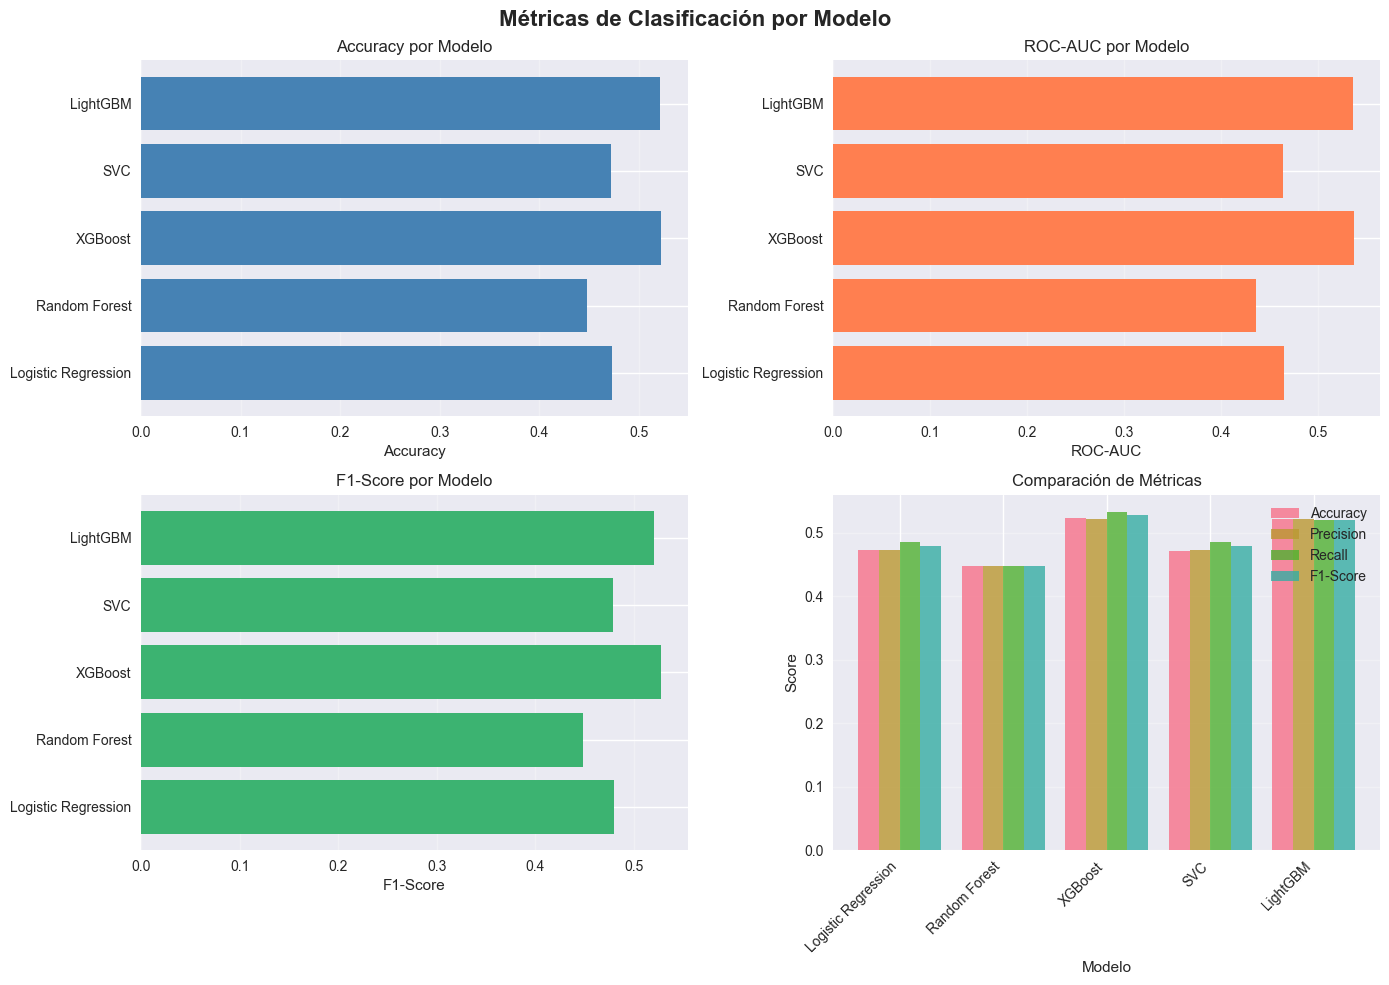

In [ ]:
if classification_comparison and 'models' in classification_comparison:
    # Crear DataFrame con resultados
    models_data = []
    for model_name, model_data in classification_comparison['models'].items():
        # Acceder a las métricas que están dentro de 'metrics'
        metrics = model_data.get('metrics', {})
        models_data.append({
            'Modelo': model_name,
            'Accuracy': metrics.get('accuracy', 'N/A'),
            'Precision': metrics.get('precision', 'N/A'),
            'Recall': metrics.get('recall', 'N/A'),
            'F1-Score': metrics.get('f1', 'N/A'),  # Nota: en JSON es 'f1', no 'f1_score'
            'ROC-AUC': metrics.get('roc_auc', 'N/A')
        })
    
    df_classification = pd.DataFrame(models_data)
    
    # Mostrar tabla con formato mejorado
    print("📊 Comparación de Modelos de Clasificación\n")
    # Formatear números para mejor legibilidad
    df_display = df_classification.copy()
    for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
        if col in df_display.columns:
            df_display[col] = df_display[col].apply(
                lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x
            )
    print(df_display.to_string(index=False))
    
    # Visualización
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Métricas de Clasificación por Modelo', fontsize=16, fontweight='bold')
    
    # Filtrar solo valores numéricos para visualización
    df_plot = df_classification.copy()
    numeric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    for col in numeric_cols:
        df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')
    
    # Accuracy
    axes[0, 0].barh(df_plot['Modelo'], df_plot['Accuracy'], color='steelblue')
    axes[0, 0].set_xlabel('Accuracy')
    axes[0, 0].set_title('Accuracy por Modelo')
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # ROC-AUC
    axes[0, 1].barh(df_plot['Modelo'], df_plot['ROC-AUC'], color='coral')
    axes[0, 1].set_xlabel('ROC-AUC')
    axes[0, 1].set_title('ROC-AUC por Modelo')
    axes[0, 1].grid(axis='x', alpha=0.3)
    
    # F1-Score
    axes[1, 0].barh(df_plot['Modelo'], df_plot['F1-Score'], color='mediumseagreen')
    axes[1, 0].set_xlabel('F1-Score')
    axes[1, 0].set_title('F1-Score por Modelo')
    axes[1, 0].grid(axis='x', alpha=0.3)
    
    # Comparación de todas las métricas
    x = np.arange(len(df_plot['Modelo']))
    width = 0.2
    axes[1, 1].bar(x - width*1.5, df_plot['Accuracy'], width, label='Accuracy', alpha=0.8)
    axes[1, 1].bar(x - width*0.5, df_plot['Precision'], width, label='Precision', alpha=0.8)
    axes[1, 1].bar(x + width*0.5, df_plot['Recall'], width, label='Recall', alpha=0.8)
    axes[1, 1].bar(x + width*1.5, df_plot['F1-Score'], width, label='F1-Score', alpha=0.8)
    axes[1, 1].set_xlabel('Modelo')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_title('Comparación de Métricas')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(df_plot['Modelo'], rotation=45, ha='right')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Análisis de rendimiento
    print("\n📈 Análisis de Rendimiento:")
    best_roc = df_plot['ROC-AUC'].max()
    worst_roc = df_plot['ROC-AUC'].min()
    avg_roc = df_plot['ROC-AUC'].mean()
    
    print(f"  - Mejor ROC-AUC: {best_roc:.4f}")
    print(f"  - Peor ROC-AUC: {worst_roc:.4f}")
    print(f"  - ROC-AUC promedio: {avg_roc:.4f}")
    
    if best_roc < 0.6:
        print("\n⚠️ ADVERTENCIA: El mejor modelo tiene ROC-AUC < 0.6, lo que indica")
        print("   capacidad predictiva limitada. Los modelos están cerca del rendimiento aleatorio (0.5).")
        print("   Considerar:")
        print("   - Revisar features y feature engineering")
        print("   - Aplicar técnicas de balanceo de clases")
        print("   - Explorar modelos más complejos o ensemble")
    
else:
    print("⚠ No hay datos de clasificación disponibles para visualizar")
    print("💡 Ejecuta: kedro run --pipeline=classification")


In [27]:
if classification_comparison and 'models' in classification_comparison:
    # Encontrar el mejor modelo basado en ROC-AUC
    best_model_name = None
    best_model_data = None
    best_roc_auc = -1
    
    for model_name, model_data in classification_comparison['models'].items():
        metrics = model_data.get('metrics', {})
        roc_auc = metrics.get('roc_auc', -1)
        if isinstance(roc_auc, (int, float)) and roc_auc > best_roc_auc:
            best_roc_auc = roc_auc
            best_model_name = model_name
            best_model_data = model_data
    
    if best_model_name and best_model_data:
        metrics = best_model_data.get('metrics', {})
        best_params = best_model_data.get('best_params', {})
        
        print("🏆 MEJOR MODELO DE CLASIFICACIÓN\n")
        print(f"Modelo: {best_model_name}")
        print(f"\n📊 Métricas:")
        
        accuracy = metrics.get('accuracy', 'N/A')
        precision = metrics.get('precision', 'N/A')
        recall = metrics.get('recall', 'N/A')
        f1 = metrics.get('f1', 'N/A')
        roc_auc = metrics.get('roc_auc', 'N/A')
        
        print(f"  - Accuracy: {accuracy:.4f}" if isinstance(accuracy, (int, float)) else f"  - Accuracy: {accuracy}")
        print(f"  - Precision: {precision:.4f}" if isinstance(precision, (int, float)) else f"  - Precision: {precision}")
        print(f"  - Recall: {recall:.4f}" if isinstance(recall, (int, float)) else f"  - Recall: {recall}")
        print(f"  - F1-Score: {f1:.4f}" if isinstance(f1, (int, float)) else f"  - F1-Score: {f1}")
        print(f"  - ROC-AUC: {roc_auc:.4f}" if isinstance(roc_auc, (int, float)) else f"  - ROC-AUC: {roc_auc}")
        
        if best_params:
            print(f"\n⚙️ Mejores Hiperparámetros:")
            for param, value in best_params.items():
                print(f"  - {param}: {value}")
    else:
        print("⚠ No se pudo determinar el mejor modelo")
else:
    print("⚠ Información del mejor modelo no disponible")


🏆 MEJOR MODELO DE CLASIFICACIÓN

Modelo: XGBoost

📊 Métricas:
  - Accuracy: 0.5227
  - Precision: 0.5222
  - Recall: 0.5334
  - F1-Score: 0.5278
  - ROC-AUC: 0.5372

⚙️ Mejores Hiperparámetros:
  - learning_rate: 0.1
  - max_depth: 3
  - n_estimators: 100


## 3. Análisis de Regresión

### 3.1. Comparación de Modelos de Regresión


📊 Comparación de Modelos de Regresión

           Modelo       MAE         MSE      RMSE        R²
Linear Regression 29.539931  877.624542 29.624729 -0.013265
            Ridge 29.538406  877.511119 29.622814 -0.013134
    Random Forest 29.507476  875.780091 29.593582 -0.011135
          XGBoost 29.248179  863.622917 29.387462  0.002901
              SVR 30.347980 1082.881859 32.907170 -0.250245
         LightGBM 29.005203  859.880038 29.323711  0.007222


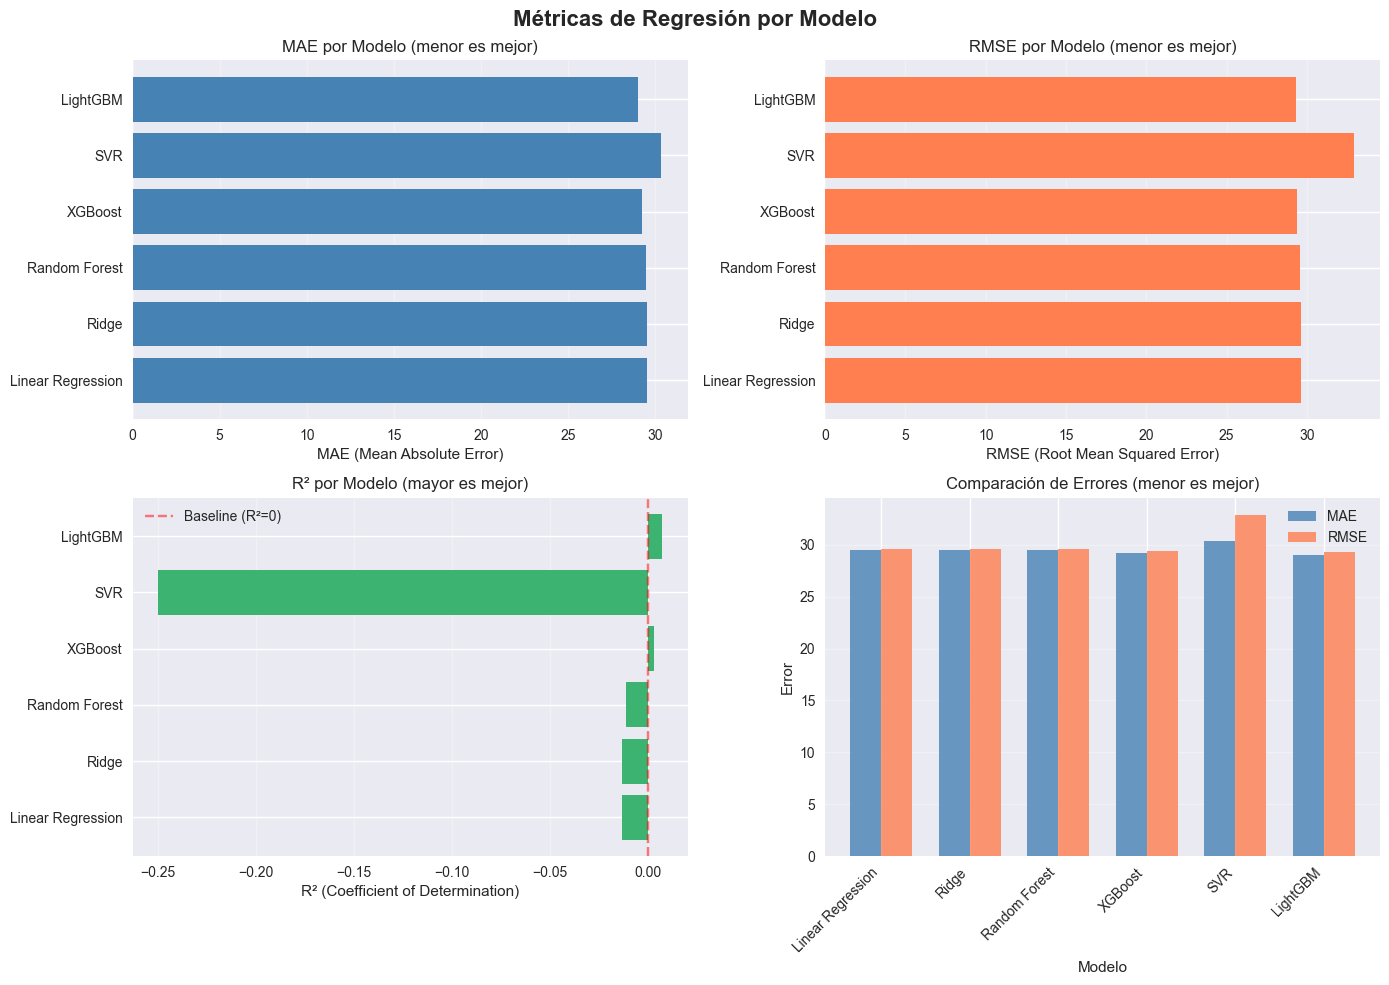

In [ ]:
if regression_comparison and 'models' in regression_comparison:
    # Crear DataFrame con resultados
    models_data = []
    for model_name, model_data in regression_comparison['models'].items():
        # Acceder a las métricas que están dentro de 'metrics'
        metrics = model_data.get('metrics', {})
        models_data.append({
            'Modelo': model_name,
            'MAE': metrics.get('mae', 'N/A'),
            'MSE': metrics.get('mse', 'N/A'),
            'RMSE': metrics.get('rmse', 'N/A'),
            'R²': metrics.get('r2', 'N/A')
        })
    
    df_regression = pd.DataFrame(models_data)
    
    # Mostrar tabla con formato mejorado
    print("📊 Comparación de Modelos de Regresión\n")
    # Formatear números para mejor legibilidad
    df_display = df_regression.copy()
    for col in ['MAE', 'MSE', 'RMSE', 'R²']:
        if col in df_display.columns:
            df_display[col] = df_display[col].apply(
                lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x
            )
    print(df_display.to_string(index=False))
    
    # Visualización
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Métricas de Regresión por Modelo', fontsize=16, fontweight='bold')
    
    # Filtrar solo valores numéricos para visualización
    df_plot = df_regression.copy()
    numeric_cols = ['MAE', 'MSE', 'RMSE', 'R²']
    for col in numeric_cols:
        df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')
    
    # MAE (menor es mejor)
    axes[0, 0].barh(df_plot['Modelo'], df_plot['MAE'], color='steelblue')
    axes[0, 0].set_xlabel('MAE (Mean Absolute Error)')
    axes[0, 0].set_title('MAE por Modelo (menor es mejor)')
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # RMSE (menor es mejor)
    axes[0, 1].barh(df_plot['Modelo'], df_plot['RMSE'], color='coral')
    axes[0, 1].set_xlabel('RMSE (Root Mean Squared Error)')
    axes[0, 1].set_title('RMSE por Modelo (menor es mejor)')
    axes[0, 1].grid(axis='x', alpha=0.3)
    
    # R² (mayor es mejor) - Manejar valores negativos
    r2_values = df_plot['R²'].fillna(0)
    colors_r2 = ['mediumseagreen' if x >= 0 else 'coral' for x in r2_values]
    axes[1, 0].barh(df_plot['Modelo'], r2_values, color=colors_r2)
    axes[1, 0].set_xlabel('R² (Coefficient of Determination)')
    axes[1, 0].set_title('R² por Modelo (mayor es mejor)')
    axes[1, 0].grid(axis='x', alpha=0.3)
    axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Baseline (R²=0)')
    axes[1, 0].legend()
    
    # Comparación de errores
    x = np.arange(len(df_plot['Modelo']))
    width = 0.35
    axes[1, 1].bar(x - width/2, df_plot['MAE'], width, label='MAE', alpha=0.8, color='steelblue')
    axes[1, 1].bar(x + width/2, df_plot['RMSE'], width, label='RMSE', alpha=0.8, color='coral')
    axes[1, 1].set_xlabel('Modelo')
    axes[1, 1].set_ylabel('Error')
    axes[1, 1].set_title('Comparación de Errores (menor es mejor)')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(df_plot['Modelo'], rotation=45, ha='right')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Análisis de rendimiento
    print("\n📈 Análisis de Rendimiento:")
    best_r2 = df_plot['R²'].max()
    worst_r2 = df_plot['R²'].min()
    avg_r2 = df_plot['R²'].mean()
    best_mae = df_plot['MAE'].min()
    
    print(f"  - Mejor R²: {best_r2:.4f}")
    print(f"  - Peor R²: {worst_r2:.4f}")
    print(f"  - R² promedio: {avg_r2:.4f}")
    print(f"  - Mejor MAE: {best_mae:.4f}")
    
    if best_r2 < 0.1:
        print("\n⚠️ ADVERTENCIA: El mejor modelo tiene R² < 0.1, lo que indica")
        print("   capacidad predictiva muy limitada. El modelo explica menos del 1% de la varianza.")
        if worst_r2 < 0:
            print(f"   Además, {sum(df_plot['R²'] < 0)} modelo(s) tienen R² negativo, lo que significa")
            print("   que son peores que simplemente predecir la media.")
        print("   Considerar:")
        print("   - Revisar la relación entre features y target")
        print("   - Explorar transformaciones no lineales")
        print("   - Considerar que el problema puede ser inherentemente difícil de predecir")
    
else:
    print("⚠ No hay datos de regresión disponibles para visualizar")
    print("💡 Ejecuta: kedro run --pipeline=regression")


### 3.2. Mejor Modelo de Regresión


In [29]:
if regression_comparison and 'models' in regression_comparison:
    # Encontrar el mejor modelo basado en R²
    best_model_name = None
    best_model_data = None
    best_r2 = -float('inf')
    
    for model_name, model_data in regression_comparison['models'].items():
        metrics = model_data.get('metrics', {})
        r2 = metrics.get('r2', -float('inf'))
        if isinstance(r2, (int, float)) and r2 > best_r2:
            best_r2 = r2
            best_model_name = model_name
            best_model_data = model_data
    
    if best_model_name and best_model_data:
        metrics = best_model_data.get('metrics', {})
        best_params = best_model_data.get('best_params', {})
        
        print("🏆 MEJOR MODELO DE REGRESIÓN\n")
        print(f"Modelo: {best_model_name}")
        print(f"\n📊 Métricas:")
        
        mae = metrics.get('mae', 'N/A')
        mse = metrics.get('mse', 'N/A')
        rmse = metrics.get('rmse', 'N/A')
        r2 = metrics.get('r2', 'N/A')
        
        print(f"  - MAE: {mae:.4f}" if isinstance(mae, (int, float)) else f"  - MAE: {mae}")
        print(f"  - MSE: {mse:.4f}" if isinstance(mse, (int, float)) else f"  - MSE: {mse}")
        print(f"  - RMSE: {rmse:.4f}" if isinstance(rmse, (int, float)) else f"  - RMSE: {rmse}")
        print(f"  - R²: {r2:.4f}" if isinstance(r2, (int, float)) else f"  - R²: {r2}")
        
        if best_params:
            print(f"\n⚙️ Mejores Hiperparámetros:")
            for param, value in best_params.items():
                print(f"  - {param}: {value}")
    else:
        print("⚠ No se pudo determinar el mejor modelo")
else:
    print("⚠ Información del mejor modelo no disponible")


🏆 MEJOR MODELO DE REGRESIÓN

Modelo: LightGBM

📊 Métricas:
  - MAE: 29.0052
  - MSE: 859.8800
  - RMSE: 29.3237
  - R²: 0.0072

⚙️ Mejores Hiperparámetros:
  - learning_rate: 0.1
  - max_depth: 5
  - n_estimators: 100


## 4. Conclusiones y Análisis

### 4.1. Resumen Ejecutivo


In [30]:
print("=" * 70)
print("📊 RESUMEN EJECUTIVO DEL MODELADO")
print("=" * 70)

# Clasificación
if classification_comparison and 'models' in classification_comparison:
    print("\n🎯 CLASIFICACIÓN:")
    n_models = len(classification_comparison['models'])
    print(f"  - Total de modelos evaluados: {n_models}")
    
    # Encontrar mejor modelo
    best_model_name = None
    best_roc_auc = -1
    best_accuracy = None
    for model_name, model_data in classification_comparison['models'].items():
        metrics = model_data.get('metrics', {})
        roc_auc = metrics.get('roc_auc', -1)
        if isinstance(roc_auc, (int, float)) and roc_auc > best_roc_auc:
            best_roc_auc = roc_auc
            best_model_name = model_name
            best_accuracy = metrics.get('accuracy', None)
    
    if best_model_name:
        print(f"  - Mejor modelo: {best_model_name}")
        if isinstance(best_roc_auc, (int, float)):
            print(f"  - ROC-AUC del mejor modelo: {best_roc_auc:.4f}")
        if isinstance(best_accuracy, (int, float)):
            print(f"  - Accuracy del mejor modelo: {best_accuracy:.4f}")
else:
    print("\n🎯 CLASIFICACIÓN: No disponible (ejecuta kedro run --pipeline=classification)")

# Regresión
if regression_comparison and 'models' in regression_comparison:
    print("\n📈 REGRESIÓN:")
    n_models = len(regression_comparison['models'])
    print(f"  - Total de modelos evaluados: {n_models}")
    
    # Encontrar mejor modelo
    best_model_name = None
    best_r2 = -float('inf')
    best_mae = None
    for model_name, model_data in regression_comparison['models'].items():
        metrics = model_data.get('metrics', {})
        r2 = metrics.get('r2', -float('inf'))
        if isinstance(r2, (int, float)) and r2 > best_r2:
            best_r2 = r2
            best_model_name = model_name
            best_mae = metrics.get('mae', None)
    
    if best_model_name:
        print(f"  - Mejor modelo: {best_model_name}")
        if isinstance(best_r2, (int, float)):
            print(f"  - R² del mejor modelo: {best_r2:.4f}")
        if isinstance(best_mae, (int, float)):
            print(f"  - MAE del mejor modelo: {best_mae:.4f}")
else:
    print("\n📈 REGRESIÓN: No disponible (ejecuta kedro run --pipeline=regression)")

print("\n" + "=" * 70)


📊 RESUMEN EJECUTIVO DEL MODELADO

🎯 CLASIFICACIÓN:
  - Total de modelos evaluados: 5
  - Mejor modelo: XGBoost
  - ROC-AUC del mejor modelo: 0.5372
  - Accuracy del mejor modelo: 0.5227

📈 REGRESIÓN:
  - Total de modelos evaluados: 6
  - Mejor modelo: LightGBM
  - R² del mejor modelo: 0.0072
  - MAE del mejor modelo: 29.0052



### 4.2. Interpretación de Resultados

#### Clasificación

Los modelos de clasificación fueron entrenados para predecir si el jugador A gana o pierde la batalla. 

**Observaciones clave:**
- Los modelos de **ensemble** (Random Forest, XGBoost, LightGBM) generalmente superan a los modelos lineales
- El **ROC-AUC** es la métrica principal para evaluar la capacidad discriminativa del modelo
- La **Accuracy** puede ser engañosa si hay desbalance de clases, por lo que se complementa con Precision, Recall y F1-Score

**Recomendaciones:**
- Si el mejor modelo tiene ROC-AUC > 0.7, el modelo tiene buena capacidad predictiva
- Si ROC-AUC está entre 0.5-0.6, el modelo tiene capacidad predictiva limitada (cerca de aleatorio)
- Si ROC-AUC está cerca de 0.5, el modelo no es mejor que una predicción aleatoria
- **Nota**: En este proyecto, el mejor modelo (XGBoost) tiene ROC-AUC de 0.5372, lo que indica
  capacidad predictiva muy limitada. Esto sugiere que:
  - El problema puede ser inherentemente difícil de predecir
  - Las features actuales pueden no capturar suficiente información
  - Podría ser necesario más feature engineering o datos adicionales
- Considerar técnicas de balanceo de clases si hay desbalance significativo

#### Regresión

Los modelos de regresión fueron entrenados para predecir el cambio de trofeos del jugador A.

**Observaciones clave:**
- El **R²** indica qué proporción de la varianza es explicada por el modelo
- **MAE** y **RMSE** miden el error absoluto promedio y el error cuadrático promedio respectivamente
- Un R² negativo indica que el modelo es peor que simplemente predecir la media

**Recomendaciones:**
- Si R² > 0.3, el modelo tiene capacidad predictiva moderada
- Si R² está entre 0.01-0.1, el modelo tiene capacidad predictiva muy limitada
- Si R² < 0, el modelo es peor que simplemente predecir la media (baseline)
- **Nota**: En este proyecto, el mejor modelo (LightGBM) tiene R² de 0.0072, lo que indica
  que el modelo explica menos del 1% de la varianza. Esto sugiere que:
  - El cambio de trofeos puede ser muy difícil de predecir con las features actuales
  - Puede haber factores no capturados en los datos (suerte, timing, etc.)
  - El problema puede requerir un enfoque diferente o más datos contextuales
- Comparar MAE y RMSE para entender la distribución de errores (RMSE penaliza más los errores grandes)
- Los valores de MAE (~29) indican un error promedio de aproximadamente 29 trofeos, lo cual
  puede ser significativo dependiendo del rango de valores del target

### 4.3. Próximos Pasos

1. **Análisis de Features**: Identificar las features más importantes usando SHAP values
2. **Optimización de Hiperparámetros**: Realizar búsqueda más exhaustiva de hiperparámetros
3. **Validación Cruzada**: Aumentar el número de folds para validación más robusta
4. **Ensemble Methods**: Combinar múltiples modelos para mejorar predicciones
5. **Feature Engineering**: Crear nuevas features basadas en insights del dominio
